In [ ]:
import torch
import torch.nn.functional as F

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-03-16 05:38:48--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-03-16 05:38:48 (8.56 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
with open("names.txt", "r") as f:
  words = [line.strip() for line in f]

words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
def char_to_idx(c):
  return 0 if c == "." else (ord(c) - ord('a') + 1)

def idx_to_char(idx):
  return '.' if idx == 0 else chr(ord('a') + idx - 1)

In [ ]:
{i: idx_to_char(i) for i in range(27)}

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [ ]:
## Preparing dataset
X, Y = [], []
block_size = 3

for word in words:
  context = [0]*block_size
  word = f"{word}."
  for char in word:
    X.append(context)
    idx = char_to_idx(char)
    Y.append(idx)
    #print("".join([idx_to_char(c) for c in context]), "->", char)
    context = context[1:] + [idx]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

### Defining a feature matrix C
So basically each character would be mapped to say [27,2] matrix, so each char is mapped to an embedding of length 2

Question:
Why do we need this feature matrix in the first place ??and why not one hot or simple index values we were using so far ?

I think the main reason is :
- simple indices don't contain any meaning e.g. say does it mean than [10] is twice as more important as [5]
- for one hot encoded, vocab of size say 100_000 (applicable in words) would mean using an input of size 100_000 Vs input of size == embedding size
- Using a feature vector means we can do some kind of clustering and build semantic meanings implicitly so that
'a cat is running' becomes a data point to give 'a dog is walking'




In [ ]:
C = torch.randn(27,2, dtype=torch.float64)
C.shape

torch.Size([27, 2])

In [ ]:
C

tensor([[ 1.0165, -1.1173],
        [ 0.9297, -1.1712],
        [-1.5647, -0.5522],
        [-1.1852, -0.8376],
        [ 0.0727, -1.7501],
        [ 1.3206,  2.4716],
        [-1.3257,  0.3299],
        [ 0.9334,  0.5623],
        [ 2.0111, -0.0967],
        [-0.5470, -1.1223],
        [-1.2982,  0.3475],
        [ 0.6093, -0.6703],
        [ 0.3274, -0.7165],
        [-2.3219,  1.6776],
        [-1.3391, -0.9778],
        [ 0.4621,  0.4152],
        [ 1.6605,  0.5284],
        [-0.4523, -0.2216],
        [-0.7762, -0.9908],
        [ 0.2562,  0.1521],
        [-0.3737, -0.2563],
        [-0.1047,  0.7860],
        [ 0.6784, -0.2278],
        [-0.6093,  2.1925],
        [ 2.3958,  0.6796],
        [ 0.3467, -0.4187],
        [-0.5839,  1.3741]], dtype=torch.float64)

In [ ]:
X[2]

tensor([ 0,  5, 13])

In [ ]:
C[X[2]] # 3 maps to 3 x 2

tensor([[ 1.0165, -1.1173],
        [ 1.3206,  2.4716],
        [-2.3219,  1.6776]], dtype=torch.float64)

In [ ]:
torch.randint(X.shape[0], (32,))

tensor([165743,  96900, 173229,  33634, 170993,  90690,  95548, 129607, 219199,
         11622,    797,   7237,  84761,  83257, 191183,  70944, 194400,  32900,
         23684, 207596,  67543, 184631, 140411, 172080, 132968, 155386, 204219,
        163336, 103858, 114317, 223665, 207778])

### Building an MLP
X  [N, 3] Y [N]

C[X] [N, 3, 2]

reshape [N, 6]

W1[6,100] b1 [100]

H = tanh(X.W1 + b1)

W2 = [100, 27] b2 = [27]

Y_pred = H2.W2 + b2

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(27,2, dtype=torch.float64)
W1 = torch.randn(6, 100, dtype=torch.float64, generator=g)
b1 = torch.randn(100, dtype=torch.float64, generator=g)
W2 = torch.randn(100, 27, dtype=torch.float64, generator=g)
b2 = torch.randn(27, dtype=torch.float64, generator=g)

parameters = [C, W1, b1, W2, b2]
for param in parameters:
  param.requires_grad = True

In [ ]:
runs = 100_000
batch_size = 32

for run in range(runs):
  # forward pass
  batch_idx = torch.randint(X.shape[0], (batch_size,))
  emb = C[X[batch_idx]]
  H = torch.tanh(emb.view(batch_size,-1) @ W1 + b1)
  logits = H @ W2 + b2
  loss = F.cross_entropy(logits, Y[batch_idx])

  #print(f"Run {run} Loss: {loss.item()}")

  # Backward pass
  for param in parameters:
    param.grad = None
  loss.backward()

  # Update params
  lr = 0.1 if run < 10_000 else 0.01
  for param in parameters:
    param.data -= lr * param.grad

print(loss.item())

2.4306185851330286


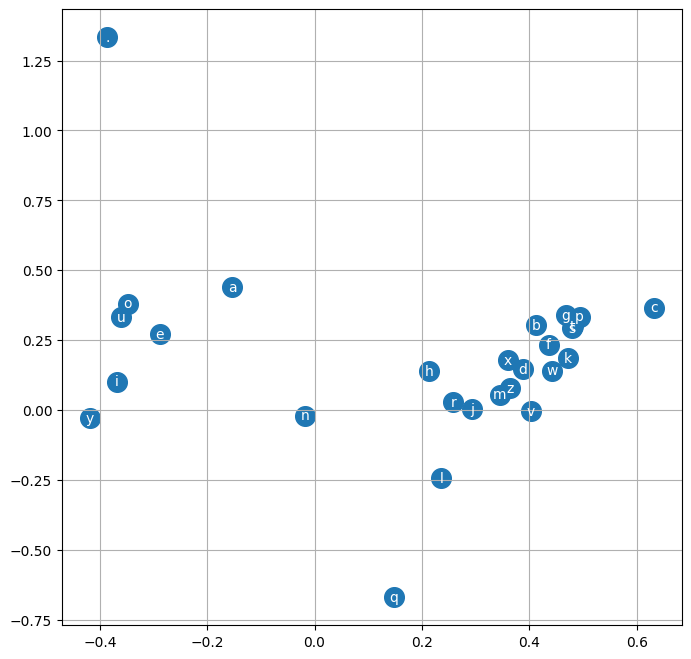

In [ ]:
# Visualize C
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), idx_to_char(i), ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# Inference
gen_num_words = 5

for _ in range(gen_num_words):
  out = []
  context = [0]*3

  while True:
    # forward pass
    ctx_tensor = torch.tensor(context) # [3]
    emb = C[ctx_tensor] # [3, 2]
    H1 = torch.tanh(emb.view(1,-1) @ W1 + b1)
    logits = H1 @ W2 + b2
    probs = F.softmax(logits, dim=1)
    new_idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()

    if new_idx == 0:
      break
    else:
      new_char = idx_to_char(new_idx)
      out.append(new_char)
      context = context[1:] + [new_idx]

  print("".join(out))

mazi
danna
tydphei
krayli
ranyane


### Experimenting with different learning rates

In [ ]:
lrs = torch.linspace(0.001,1,1000)
lrs

tensor([0.0010, 0.0020, 0.0030, 0.0040, 0.0050, 0.0060, 0.0070, 0.0080, 0.0090,
        0.0100, 0.0110, 0.0120, 0.0130, 0.0140, 0.0150, 0.0160, 0.0170, 0.0180,
        0.0190, 0.0200, 0.0210, 0.0220, 0.0230, 0.0240, 0.0250, 0.0260, 0.0270,
        0.0280, 0.0290, 0.0300, 0.0310, 0.0320, 0.0330, 0.0340, 0.0350, 0.0360,
        0.0370, 0.0380, 0.0390, 0.0400, 0.0410, 0.0420, 0.0430, 0.0440, 0.0450,
        0.0460, 0.0470, 0.0480, 0.0490, 0.0500, 0.0510, 0.0520, 0.0530, 0.0540,
        0.0550, 0.0560, 0.0570, 0.0580, 0.0590, 0.0600, 0.0610, 0.0620, 0.0630,
        0.0640, 0.0650, 0.0660, 0.0670, 0.0680, 0.0690, 0.0700, 0.0710, 0.0720,
        0.0730, 0.0740, 0.0750, 0.0760, 0.0770, 0.0780, 0.0790, 0.0800, 0.0810,
        0.0820, 0.0830, 0.0840, 0.0850, 0.0860, 0.0870, 0.0880, 0.0890, 0.0900,
        0.0910, 0.0920, 0.0930, 0.0940, 0.0950, 0.0960, 0.0970, 0.0980, 0.0990,
        0.1000, 0.1010, 0.1020, 0.1030, 0.1040, 0.1050, 0.1060, 0.1070, 0.1080,
        0.1090, 0.1100, 0.1110, 0.1120, 

In [ ]:
# This is preferable because Log spacing gives equal attention to each order of magnitude.
lrs = torch.linspace(-3,-1,1000)
lrs = 10**lrs
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
        0.0010, 0.0010, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 

In [ ]:
# Assiging a different learning rate at each run

runs = 1000
batch_size = 32
lossi = []
stepi = []
lrsi = []

for i in range(runs):
  # forward pass
  batch_idx = torch.randint(X.shape[0], (batch_size,))
  emb = C[X[batch_idx]]
  X1 = torch.tanh(emb.view(batch_size,-1) @ W1 + b1)
  logits = X1 @ W2 + b2
  loss = F.cross_entropy(logits, Y[batch_idx])

  #print(f"Run {run} Loss: {loss.item()}")

  # Backward pass
  for param in parameters:
    param.grad = None
  loss.backward()

  # Update params
  for param in parameters:
    param.data -= lrs[i] * param.grad

  stepi.append(i)
  lrsi.append(lrs[i])
  lossi.append(loss.item())

#print(loss.item())

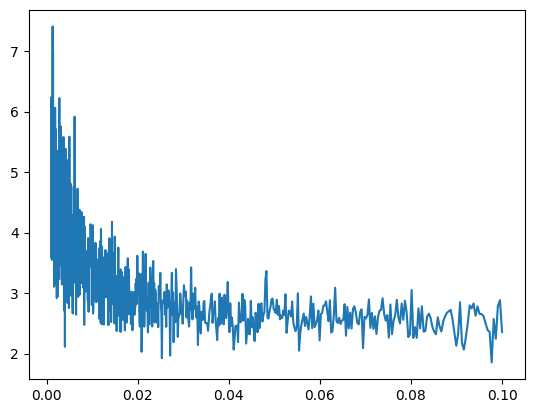

In [ ]:
plt.plot(lrsi, lossi)

#### TRYING DIFFERENT EMBEDDING SIZE AND HIDDEN LAYERS


In [ ]:
# params
C  = torch.randn(27, 10, dtype=torch.float64, generator=g)
W1 = torch.randn(30, 100, dtype=torch.float64, generator=g)
b1 = torch.randn(100, dtype=torch.float64, generator=g)
W2 = torch.randn(100, 27, dtype=torch.float64, generator=g)
b2 = torch.randn(27, dtype=torch.float64, generator=g)

parameters = [C, W1, b1, W2, b2]
for param in parameters:
  param.requires_grad = True

In [40]:
runs = 100_000
batch_size = 32

for run in range(runs):
  # forward pass
  batch_idx = torch.randint(X.shape[0], (batch_size,))
  emb = C[X[batch_idx]]
  X1 = torch.tanh(emb.view(batch_size,-1) @ W1 + b1)
  logits = X1 @ W2 + b2
  loss = F.cross_entropy(logits, Y[batch_idx])

  # Backward pass
  for param in parameters:
    param.grad = None
  loss.backward()

  # Update params
  lr = 0.1 if run < 10000 else 0.01
  for param in parameters:
    param.data -= lr * param.grad

print(f"Final loss: {loss.item()}")

Streaming output truncated to the last 5000 lines.
Run 95001 Loss: 1.8764416628856888
Run 95002 Loss: 2.5152244751212405
Run 95003 Loss: 2.6614592640674872
Run 95004 Loss: 2.133466994732052
Run 95005 Loss: 2.3427857860820027
Run 95006 Loss: 2.4485656885066907
Run 95007 Loss: 2.6749335391848676
Run 95008 Loss: 2.571727080050789
Run 95009 Loss: 2.424980931963429
Run 95010 Loss: 2.193146850424137
Run 95011 Loss: 2.041661825365824
Run 95012 Loss: 2.3839370805318927
Run 95013 Loss: 2.44991935132078
Run 95014 Loss: 2.246050544883594
Run 95015 Loss: 2.0062169173656206
Run 95016 Loss: 2.4063757000044887
Run 95017 Loss: 2.252056728466862
Run 95018 Loss: 2.0181660132786816
Run 95019 Loss: 2.6044235222913117
Run 95020 Loss: 2.539351496497202
Run 95021 Loss: 1.9870112243449893
Run 95022 Loss: 1.8941116356236773
Run 95023 Loss: 2.076476283347623
Run 95024 Loss: 1.8849579985140954
Run 95025 Loss: 2.5894628014542094
Run 95026 Loss: 2.240723588238893
Run 95027 Loss: 2.6849703945258976
Run 95028 Loss: 

In [ ]:
## Preparing dataset
X, Y = [], []
block_size = 3

for word in words:
  context = [0]*block_size
  word = f"{word}."
  for char in word:
    X.append(context)
    idx = char_to_idx(char)
    Y.append(idx)
    context = context[1:] + [idx]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

### DATA split
Testing on train/dev/test

In [42]:
def build_dataset(words):
  X, Y = [], []
  block_size = 3

  for word in words:
    context = [0]*block_size
    word = f"{word}."
    for char in word:
      X.append(context)
      idx = char_to_idx(char)
      Y.append(idx)
      context = context[1:] + [idx]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

In [43]:
import random
random.shuffle(words)

split_train = int(0.8 * len(words))
split_val = int(0.9 * len(words))
X_tr, Y_tr = build_dataset(words[:split_train])
X_val, Y_val = build_dataset(words[split_train:split_val])
X_test, Y_test = build_dataset(words[split_val])

In [44]:
X_tr.shape, X_val.shape

(torch.Size([182564, 3]), torch.Size([22867, 3]))

In [61]:
# params
C  = torch.randn(27, 15, dtype=torch.float64, generator=g)
W1 = torch.randn(30, 200, dtype=torch.float64, generator=g)
b1 = torch.randn(200, dtype=torch.float64, generator=g)
W2 = torch.randn(200, 27, dtype=torch.float64, generator=g)
b2 = torch.randn(27, dtype=torch.float64, generator=g)

parameters = [C, W1, b1, W2, b2]
for param in parameters:
  param.requires_grad = True

In [65]:
runs = 300_000
batch_size = 32

for run in range(runs):
  # forward pass
  batch_idx = torch.randint(X_tr.shape[0], (batch_size,))
  emb = C[X_tr[batch_idx]]
  H = torch.tanh(emb.view(batch_size,-1) @ W1 + b1)
  logits = H @ W2 + b2
  loss = F.cross_entropy(logits, Y_tr[batch_idx])

  # Backward pass
  for param in parameters:
    param.grad = None
  loss.backward()

  # Update params
  if run < 10_000:
    lr = 0.1
  elif run < 50_000:
    lr = 0.01
  elif run < 100_000:
    lr = 0.005
  elif run < 200_000:
    lr = 0.002
  else:
    lr = 0.001
  for param in parameters:
    param.data -= lr * param.grad

print(f"Final loss: {loss.item()}")

Final loss: 2.1449620785631334


In [66]:
### Evaluating loss on validation set
emb2 = C[X_val] # [22867, 3, 10]
H2 = torch.tanh(emb2.view(X_val.shape[0], -1) @ W1 + b1) # [22867, 200]
logits = H2 @ W2 + b2 # [22867, 27]
val_loss = F.cross_entropy(logits, Y_val)
val_loss

tensor(2.2173, dtype=torch.float64, grad_fn=<NllLossBackward0>)

In [67]:
# Inference
gen_num_words = 10

for _ in range(gen_num_words):
  out = []
  context = [0]*3

  while True:
    # forward pass
    ctx_tensor = torch.tensor(context) # [3]
    emb = C[ctx_tensor] # [3, 2]
    H1 = torch.tanh(emb.view(1,-1) @ W1 + b1)
    logits = H1 @ W2 + b2
    probs = F.softmax(logits, dim=1)
    new_idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()

    if new_idx == 0:
      break
    else:
      new_char = idx_to_char(new_idx)
      out.append(new_char)
      context = context[1:] + [new_idx]

  print("".join(out))

dabetryn
karlynn
rogen
dyan
miselegrantreanna
shafeniss
corste
wenna
deva
yaverh
